# POS-теггер для русского языка, устойчивый к опечаткам

## 📋 Постановка бизнес-задачи

**Контекст**  
Вы работаете в компании, разрабатывающей интеллектуальную систему проверки грамматики и стиля для русского языка «Грамотей». Пользователи часто вводят текст с опечатками (например, «карова» вместо «корова», «здарова» вместо «здорово»), из‑за чего текущий модуль анализа морфологии выдаёт ошибки. Нужен прототип, который **корректно определяет UPOS-тег для каждого слова даже в предложениях с опечатками**.

**Задача**  
Разработать **POS-теггер для русского языка, устойчивый к опечаткам**.

- **Вход:** последовательность токенов (слова, возможно с опечатками).
- **Выход:** последовательность UPOS-тегов (17 классов UD).

**Метрика:** Token Accuracy на `test_noisy`.  
**Бизнес-критерий:** Accuracy ≥ **0.88**.

**Подход:**
- Кандидаты исправлений: **Trie + BFS** (расстояние Дамерау–Левенштейна ≤ `max_dist`).
- Вероятность опечатки: **ErrorModel** (практика 31).
- Контекст тегов: **HMM + Витерби** (NLTK, практика 32).

> **Важно:** не используйте `pyspellchecker` и другие готовые spell-check библиотеки. DL, Trie, ErrorModel — вручную. HMM — NLTK.


## 📊 Данные

### 1. Universal Dependencies — Russian SynTagRus
```python
from datasets import load_dataset
dataset = load_dataset("commul/universal_dependencies", "ru_syntagrus")
```
~48k train, ~6k dev, ~6k test. Поля: `tokens`, `upos`, `lemmas`, `feats`.

### 2. Kartaslov orfo_and_typos (практика 31)
Локальный файл: `data/orfo_and_typos.csv` (столбцы: `CORRECT`, `MISTAKE`, `WEIGHT`).

### Оценка
- `train`, `dev` — чистые предложения (обучение HMM).
- `test_clean` — оригинальный test.
- `test_noisy` — test с опечатками (p=0.15 на слово; операции: sub 0.5, del 0.2, ins 0.2, trans 0.1). Gold-теги — из чистого test.


---
## Подготовка окружения

Заполните ячейку ниже: импорты, константы, пути к данным.

Рекомендуемые константы: `RANDOM_STATE`, `MIN_WORD_COUNT`, `UNK_TOKEN`, `NUM_TOKEN`, `TARGET_ACCURACY=0.80`, `TYPO_PROB=0.15`, `ALPHA_ERROR=0.01`.


In [2]:
# импорты, константы, создание папки artifacts

import os
from pathlib import Path
import json
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import math
import time

from datasets import load_dataset
from nltk.tag.hmm import HiddenMarkovModelTrainer
from numpy.ma.extras import unique
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pickle

from collections import Counter,defaultdict, deque
from typing import Dict, List, Optional, Tuple


RANDOM_STATE = 42
MIN_WORD_COUNT = 2
UNK_TOKEN = '<UNK>'
NUM_TOKEN = '<NUM>'
TARGET_ACCURACY = 0.88
TYPO_PROB = 0.15
GAMMA = 0.1
MAX_EDIT_DIST = 2
ALPHA_ERROR = 0.01    # сглаживание ErrorModel (шаг 3)
ALPHA_LM = 1e-6       # сглаживание языковой модели, Лаплас (шаг 6)
TEST_SAMPLE = 100_000   # размер тестовой подвыборки для оценки
DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")
TYPOS_PATH = DATA_DIR/'orfo_and_typos.csv'
DATA_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR.mkdir(exist_ok=True)

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Готово. Целевая accuracy:", TARGET_ACCURACY)

C:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Готово. Целевая accuracy: 0.88


---
## Шаг 1. Загрузка данных и первичный осмотр

- Загрузите `ru_syntagrus` через `datasets`.
- Выведите число предложений и токенов в каждом сплите.
- Загрузите CSV опечаток, покажите `head()`, проверьте пропуски.


In [3]:
# загрузка UD (ru_syntagrus)
dataset_ru_syntagrus = load_dataset("commul/universal_dependencies", "ru_syntagrus")

In [27]:
print(dataset_ru_syntagrus)
print('-'*100)
print(f'Dataset Keys: {dataset_ru_syntagrus.keys()}')
print('-'*100)
print(f'Train Len = {len(dataset_ru_syntagrus["train"])} , Test Len = {len(dataset_ru_syntagrus["test"])}, Val Len = {len(dataset_ru_syntagrus["dev"])}')
print('-'*100)
print(f'{dataset_ru_syntagrus['train'][1]}')
print('-'*100)
print(f'{sum(len(t) for t in dataset_ru_syntagrus["train"]["tokens"])} - Train Tokens, {sum(len(t) for t in dataset_ru_syntagrus["test"]["tokens"])} - Test Tokens, '
      f'{sum(len(t) for t in dataset_ru_syntagrus["dev"]["tokens"])} - Validation Tokens')
print('-'*100)
dataset_ru_syntagrus["train"].features['upos']

DatasetDict({
    dev: Dataset({
        features: ['sent_id', 'text', 'comments', 'tokens', 'lemmas', 'upos', 'xpos', 'feats', 'head', 'deprel', 'deps', 'misc', 'mwt', 'empty_nodes'],
        num_rows: 8906
    })
    test: Dataset({
        features: ['sent_id', 'text', 'comments', 'tokens', 'lemmas', 'upos', 'xpos', 'feats', 'head', 'deprel', 'deps', 'misc', 'mwt', 'empty_nodes'],
        num_rows: 8800
    })
    train: Dataset({
        features: ['sent_id', 'text', 'comments', 'tokens', 'lemmas', 'upos', 'xpos', 'feats', 'head', 'deprel', 'deps', 'misc', 'mwt', 'empty_nodes'],
        num_rows: 69631
    })
})
----------------------------------------------------------------------------------------------------
Dataset Keys: dict_keys(['dev', 'test', 'train'])
----------------------------------------------------------------------------------------------------
Train Len = 69631 , Test Len = 8800, Val Len = 8906
------------------------------------------------------------------------

List(Value('string'))

In [13]:
tags_lst = sorted({tag for sent in dataset_ru_syntagrus["train"]["upos"] for tag in sent})
print(tags_lst)

['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X']


In [15]:
# загрузка orfo_and_typos.csv
import urllib.request

TYPOS_URL = ("https://raw.githubusercontent.com/dkulagin/kartaslov/"
             "master/dataset/orfo_and_typos/orfo_and_typos.L1_5.csv")

if not TYPOS_PATH.exists():
    print("Скачиваю датасет опечаток...")
    urllib.request.urlretrieve(TYPOS_URL, TYPOS_PATH)
    print("Готово")
else:
    print("Файл уже на месте")

Скачиваю датасет опечаток...
Готово


In [23]:
orfo_df = pd.read_csv(TYPOS_PATH, sep=";")
print(orfo_df.head())
print('-'*100)
print(orfo_df.describe())

  CORRECT  MISTAKE  WEIGHT
0  болото   болотл  0.3333
1  болото  болотао  0.2500
2  болото   балото  0.1219
3  болото    болто  0.0562
4  болото  болотаъ  0.0526
----------------------------------------------------------------------------------------------------
             WEIGHT
count  85550.000000
mean       0.198534
std        0.170689
min        0.000000
25%        0.052600
50%        0.142900
75%        0.333300
max        0.947400


In [48]:
orfo_df.columns = ["correct", "typo", "weight"]
print("Колонки:", orfo_df.columns.tolist())
print('-'*100)
print("Пропуски:\n", orfo_df.isnull().sum())
print('-'*100)
print("Дубликаты:", orfo_df.duplicated().sum())
print('-'*100)
print("Нулевые значения:", sum(orfo_df['weight']==0))
print('-'*100)
print("Совпадения correct и typo:", sum(orfo_df['typo']==orfo_df['correct']))
print('-'*100)
print("Посторонние символы в correct:", orfo_df["correct"].str.contains(r"[^а-яё]").sum())
print('-'*100)
print("Посторонние символы в typo:", orfo_df["typo"].str.contains(r"[^а-яё]").sum())
print('-'*100)
print(orfo_df[orfo_df["correct"].str.contains(r"[^а-яё]")].head())
print('-'*100)
print((orfo_df["correct"] != orfo_df["correct"].str.lower()).sum())
orfo_df.describe(include="all")

Колонки: ['correct', 'typo', 'weight']
----------------------------------------------------------------------------------------------------
Пропуски:
 correct    0
typo       0
weight     0
dtype: int64
----------------------------------------------------------------------------------------------------
Дубликаты: 0
----------------------------------------------------------------------------------------------------
Нулевые значения: 1
----------------------------------------------------------------------------------------------------
Совпадения correct и typo: 0
----------------------------------------------------------------------------------------------------
Посторонние символы в correct: 72
----------------------------------------------------------------------------------------------------
Посторонние символы в typo: 103
----------------------------------------------------------------------------------------------------
               correct             typo  weight
11924          

,correct,typo,weight
count,85550,85550,85550.000000
unique,21749,69338,NaN
top,что,см,NaN
freq,122,51,NaN
mean,NaN,NaN,0.198534
std,NaN,NaN,0.170689
min,NaN,NaN,0.000000
25%,NaN,NaN,0.052600
50%,NaN,NaN,0.142900
75%,NaN,NaN,0.333300


---
## Шаг 2. EDA

- Гистограмма длин предложений (train).
- Barplot частот UPOS-тегов.
- Топ-10 омонимов (слова с >1 тегом).
- Гистограмма DL между correct и typo.
- (Опционально) частоты операций sub/ins/del/trans в ErrorModel.


In [73]:
# EDA — длины предложений и частоты тегов
df_tokens_len = [len(t) for t in dataset_ru_syntagrus["train"]["tokens"]]
print(df_tokens_len[:10])

tag_freq = Counter(tag for sent in dataset_ru_syntagrus["train"]["upos"] for tag in sent)
print(tag_freq)

[2, 34, 34, 19, 8, 15, 37, 8, 16, 19]
Counter({'NOUN': 288812, 'PUNCT': 222018, 'VERB': 140221, 'ADJ': 112833, 'ADP': 112204, 'ADV': 57763, 'PRON': 52021, 'CCONJ': 43715, 'DET': 43619, 'PART': 40276, 'PROPN': 39433, 'SCONJ': 22678, 'NUM': 14121, 'AUX': 10833, 'X': 2771, 'SYM': 1043, 'INTJ': 183})


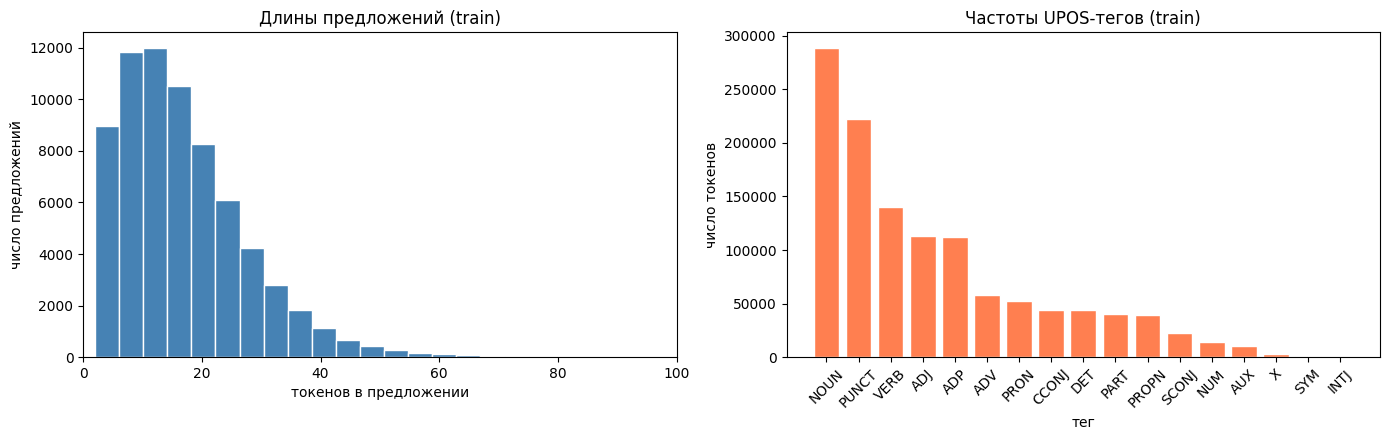

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(df_tokens_len, bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlim(0, 100)
axes[0].set_title("Длины предложений (train)")
axes[0].set_xlabel("токенов в предложении")
axes[0].set_ylabel("число предложений")

tags, counts = zip(*tag_freq.most_common())
axes[1].bar(tags, counts, color="coral", edgecolor="white")
axes[1].set_title("Частоты UPOS-тегов (train)")
axes[1].set_xlabel("тег")
axes[1].set_ylabel("число токенов")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [99]:
# EDA — омонимы
word_tags = defaultdict(Counter)
for tokens, tags in zip(dataset_ru_syntagrus["train"]["tokens"],
                        dataset_ru_syntagrus["train"]["upos"]):
    for word, tag in zip(tokens, tags):
        word_tags[word.lower()][tag] += 1

print(word_tags["стали"])
print('-'*100)

Counter({'VERB': 367, 'NOUN': 21})
----------------------------------------------------------------------------------------------------


In [109]:
homonyms = {w: c for w, c in word_tags.items() if len(c) > 1}
top_10_homonyms = sorted(homonyms, key=lambda w: word_tags[w].most_common(2)[1][1], reverse=True)[:10]

print("Топ-10 омонимов (по частоте второго тега):")
for i, h in enumerate(top_10_homonyms, start=1):
    print(f"{i:2}. {h:8} {word_tags[h].most_common(3)}")

print("-" * 100)

hom_tokens = sum(sum(c.values()) for c in homonyms.values())
total_tokens = tag_freq.total()

print(f"Омонимов: {len(homonyms)} из {len(word_tags)} слов "
      f"({len(homonyms) / len(word_tags):.1%} словаря)")
print(f"На них приходится {hom_tokens} токенов "
      f"({hom_tokens / total_tokens:.1%} корпуса)")


Топ-10 омонимов (по частоте второго тега):
 1. и        [('CCONJ', 27709), ('PART', 4985), ('X', 3)]
 2. что      [('SCONJ', 8730), ('PRON', 2344), ('ADV', 28)]
 3. его      [('DET', 1779), ('PRON', 1680)]
 4. все      [('DET', 1559), ('PRON', 1379), ('PART', 575)]
 5. как      [('SCONJ', 4494), ('ADV', 1375), ('PART', 1)]
 6. то       [('PRON', 1337), ('SCONJ', 1201), ('DET', 307)]
 7. их       [('PRON', 1335), ('DET', 1017)]
 8. это      [('PRON', 4256), ('PART', 805), ('DET', 520)]
 9. ее       [('PRON', 930), ('DET', 729)]
10. еще      [('ADV', 1430), ('PART', 609)]
----------------------------------------------------------------------------------------------------
Омонимов: 2230 из 121666 слов (1.8% словаря)
На них приходится 324956 токенов (27.0% корпуса)


In [110]:
def damerau_levenshtein(s1: str, s2: str, max_dist: int | None = None) -> int:
    """Расстояние Дамерау-Левенштейна (вставка, удаление, замена, транспозиция)."""
    m, n = len(s1), len(s2)

    if max_dist is not None and abs(m - n) > max_dist:
        return max_dist + 1

    d = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        d[i][0] = i
    for j in range(n + 1):
        d[0][j] = j

    for i in range(1, m + 1):
        row_min = d[i][0]

        for j in range(1, n + 1):
            cost = 0 if s1[i - 1] == s2[j - 1] else 1

            d[i][j] = min(
                d[i - 1][j] + 1,
                d[i][j - 1] + 1,
                d[i - 1][j - 1] + cost,
            )

            if (i > 1 and j > 1
                    and s1[i - 1] == s2[j - 2]
                    and s1[i - 2] == s2[j - 1]):
                d[i][j] = min(d[i][j], d[i - 2][j - 2] + cost)

            row_min = min(row_min, d[i][j])

        if max_dist is not None and row_min > max_dist:
            return max_dist + 1

    return d[m][n]

In [111]:
tests = [("кот", "кто", 1), ("болото", "балото", 1), ("привет", "првиет", 1),
         ("карова", "корова", 1), ("здарова", "здорово", 2), ("дом", "дом", 0)]

for a, b, expected in tests:
    got = damerau_levenshtein(a, b)
    print(f"{'OK ' if got == expected else 'FAIL'} {a!r} → {b!r}: {got} (ждали {expected})")

OK  'кот' → 'кто': 1 (ждали 1)
OK  'болото' → 'балото': 1 (ждали 1)
OK  'привет' → 'првиет': 1 (ждали 1)
OK  'карова' → 'корова': 1 (ждали 1)
OK  'здарова' → 'здорово': 2 (ждали 2)
OK  'дом' → 'дом': 0 (ждали 0)


In [112]:
# EDA — расстояния между эталоном и опечаткой
dl_dists = [damerau_levenshtein(c, t) for c, t in zip(orfo_df["correct"], orfo_df["typo"])]
dist_freq = Counter(dl_dists)
total_pairs = len(dl_dists)

for d in sorted(dist_freq):
    print(f"DL={d}: {dist_freq[d]:>6}  ({dist_freq[d] / total_pairs:.2%})")

beyond = sum(v for k, v in dist_freq.items() if k > MAX_EDIT_DIST)
print(f"\nЗа порогом max_dist={MAX_EDIT_DIST}: {beyond} пар ({beyond / total_pairs:.2%}) — "
      f"их система исправить не сможет в принципе")

DL=1:  60217  (70.39%)
DL=2:  25102  (29.34%)
DL=3:    216  (0.25%)
DL=4:     13  (0.02%)
DL=5:      1  (0.00%)
DL=8:      1  (0.00%)

За порогом max_dist=2: 231 пар (0.27%) — их система исправить не сможет в принципе


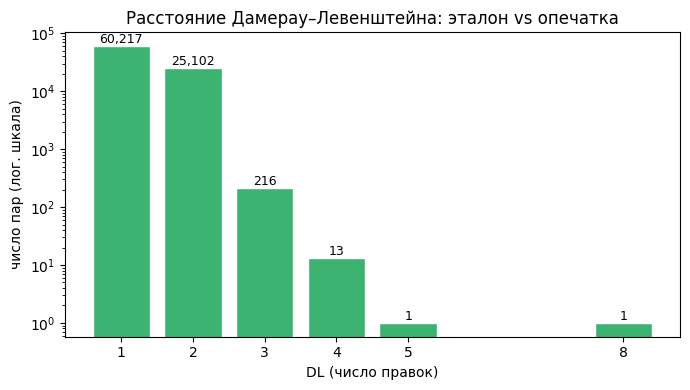

In [113]:
dists, counts_dl = zip(*sorted(dist_freq.items()))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(dists, counts_dl, color="mediumseagreen", edgecolor="white")

ax.set_yscale("log")
ax.set_title("Расстояние Дамерау–Левенштейна: эталон vs опечатка")
ax.set_xlabel("DL (число правок)")
ax.set_ylabel("число пар (лог. шкала)")
ax.set_xticks(dists)

for bar, cnt in zip(bars, counts_dl):
    ax.text(bar.get_x() + bar.get_width() / 2, cnt, f"{cnt:,}",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

---
## Шаг 3. Предобработка

- lower case для токенов UD.
- Частотный словарь по train; редкие слова (<2) → `<UNK>`, цифры → `<NUM>`.
- Очистка опечаток: только кириллица, без дубликатов, correct ≠ typo.
- Обучите `ErrorModel` (α=0.01) на парах (correct, typo, weight).


In [118]:
# предобработка токенов UD, формат [(слово, тег), ...]
NUM_RE = re.compile(r"^\d+([.,\-/]\d+)*$")
word_freq = Counter(w.lower() for s in dataset_ru_syntagrus["train"]["tokens"] for w in s)
def normalize(token, word_freq):
    token = token.lower()

    if NUM_RE.match(token):
        return NUM_TOKEN

    if word_freq[token] < MIN_WORD_COUNT:
        return UNK_TOKEN

    return token

In [119]:
def build_sents(split, word_freq):
    sents = []

    for tokens, tags in zip(split["tokens"], split["upos"]):
        sent = []
        for word, tag in zip(tokens, tags):
            sent.append((normalize(word, word_freq), tag))
        sents.append(sent)

    return sents

train_sents      = build_sents(dataset_ru_syntagrus["train"], word_freq)
dev_sents        = build_sents(dataset_ru_syntagrus["dev"], word_freq)
test_clean_sents = build_sents(dataset_ru_syntagrus["test"], word_freq)

In [126]:
print(f'Длины сплитов: Train {len(train_sents)}, Dev {len(dev_sents)}, Test {len(test_clean_sents)}')
print(f'Пример сплита {train_sents[1][:5]}')

Длины сплитов: Train 69631, Dev 8906, Test 8800
Пример сплита [('начальник', 'NOUN'), ('областного', 'ADJ'), ('управления', 'NOUN'), ('связи', 'NOUN'), ('семен', 'PROPN')]


In [128]:
def unk_share(sents):
    words = [word for sent in sents for word, _ in sent]
    return words.count(UNK_TOKEN) / len(words)

for name, sents in [("train", train_sents), ("dev", dev_sents), ("test", test_clean_sents)]:
    print(f"{name}: {unk_share(sents):.2%}")

train: 5.27%
dev: 11.36%
test: 10.42%


In [129]:
CYR = r"[а-яё]+"

typos_df = orfo_df.copy()

# приведение к единому виду
typos_df["correct"] = typos_df["correct"].astype(str).str.lower().str.strip()
typos_df["typo"] = typos_df["typo"].astype(str).str.lower().str.strip()
typos_df["weight"] = pd.to_numeric(typos_df["weight"], errors="coerce")

before = len(typos_df)

# фильтры
typos_df = typos_df.dropna(subset=["correct", "typo", "weight"])
typos_df = typos_df[typos_df["weight"] > 0]
typos_df = typos_df[typos_df["correct"] != typos_df["typo"]]
typos_df = typos_df[typos_df["correct"].str.fullmatch(CYR) & typos_df["typo"].str.fullmatch(CYR)]
typos_df = typos_df.drop_duplicates(subset=["correct", "typo"]).reset_index(drop=True)

print(f"Было: {before}, стало: {len(typos_df)} (удалено {before - len(typos_df)})")

Было: 85550, стало: 85399 (удалено 151)


In [130]:
class ErrorModel:
    ALPHABET_SIZE = 33

    def __init__(self, alpha=0.01):
        self.alpha = alpha
        self.sub = defaultdict(Counter)
        self.ins = Counter()
        self.delete = Counter()
        self.trans = defaultdict(Counter)
        self._totals = {}
        self._cache = {}


    def _matrix(self, w, t):
        m, n = len(w), len(t)
        d = [[0] * (n + 1) for _ in range(m + 1)]
        for i in range(m + 1):
            d[i][0] = i
        for j in range(n + 1):
            d[0][j] = j
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                cost = 0 if w[i - 1] == t[j - 1] else 1
                d[i][j] = min(d[i - 1][j] + 1, d[i][j - 1] + 1, d[i - 1][j - 1] + cost)
                if (i > 1 and j > 1
                        and w[i - 1] == t[j - 2] and w[i - 2] == t[j - 1]):
                    d[i][j] = min(d[i][j], d[i - 2][j - 2] + cost)
        return d

    def _align(self, w, t):
        d = self._matrix(w, t)
        ops = []
        i, j = len(w), len(t)

        while i > 0 or j > 0:
            if i > 0 and j > 0 and w[i - 1] == t[j - 1] and d[i][j] == d[i - 1][j - 1]:
                i, j = i - 1, j - 1
            # перестановка двух соседних букв
            elif (i > 1 and j > 1
                  and w[i - 1] == t[j - 2] and w[i - 2] == t[j - 1]
                  and d[i][j] == d[i - 2][j - 2] + 1):
                ops.append(("trans", w[i - 2], w[i - 1]))
                i, j = i - 2, j - 2
            # замена буквы
            elif i > 0 and j > 0 and d[i][j] == d[i - 1][j - 1] + 1:
                ops.append(("sub", w[i - 1], t[j - 1]))
                i, j = i - 1, j - 1
            # лишняя буква в опечатке
            elif j > 0 and d[i][j] == d[i][j - 1] + 1:
                ops.append(("ins", t[j - 1]))
                j -= 1
            # пропущенная буква
            elif i > 0 and d[i][j] == d[i - 1][j] + 1:
                ops.append(("del", w[i - 1]))
                i -= 1
            else:
                break

        return ops[::-1]


    def fit(self, pairs):
        for w, t, weight in pairs:
            for op in self._align(w, t):
                kind = op[0]
                if kind == "sub":
                    self.sub[op[1]][op[2]] += weight
                elif kind == "ins":
                    self.ins[op[1]] += weight
                elif kind == "del":
                    self.delete[op[1]] += weight
                elif kind == "trans":
                    self.trans[op[1]][op[2]] += weight

        smoothing = self.alpha * self.ALPHABET_SIZE
        self._totals = {
            "ins": sum(self.ins.values()) + smoothing,
            "del": sum(self.delete.values()) + smoothing,
            "sub": {c: sum(v.values()) + smoothing for c, v in self.sub.items()},
            "trans": {c: sum(v.values()) + smoothing for c, v in self.trans.items()},
        }
        self._cache.clear()
        return self


    def _op_log_prob(self, op):
        kind = op[0]
        smoothing = self.alpha * self.ALPHABET_SIZE
        if kind == "sub":
            count = self.sub[op[1]][op[2]]
            total = self._totals["sub"].get(op[1], smoothing)
        elif kind == "trans":
            count = self.trans[op[1]][op[2]]
            total = self._totals["trans"].get(op[1], smoothing)
        elif kind == "ins":
            count = self.ins[op[1]]
            total = self._totals["ins"]
        else:
            count = self.delete[op[1]]
            total = self._totals["del"]
        return math.log((count + self.alpha) / total)

    def log_prob(self, w, t):
        if w == t:
            return 0.0

        key = (w, t)
        if key in self._cache:
            return self._cache[key]

        result = sum(self._op_log_prob(op) for op in self._align(w, t))
        self._cache[key] = result
        return result

In [131]:
error_model = ErrorModel(alpha=ALPHA_ERROR).fit(zip(typos_df["correct"], typos_df["typo"], typos_df["weight"]))

In [132]:
op_counts = Counter()
for w, t in zip(typos_df["correct"], typos_df["typo"]):
    for op in error_model._align(w, t):
        op_counts[op[0]] += 1

print("Распределение операций в датасете:", op_counts.most_common())
print("Топ замен для «о»:", error_model.sub["о"].most_common(5))
for w, t in [("корова", "карова"), ("корова", "корова"), ("корова", "щорова")]:
    print(f"log P({t!r} | {w!r}) = {error_model.log_prob(w, t):.3f}")

Распределение операций в датасете: [('sub', 60257), ('ins', 26239), ('del', 24464)]
Топ замен для «о»: [('а', 537.3742765180776), ('е', 92.32790596754056), ('и', 77.16281850567991), ('р', 74.85688449743779), ('л', 68.69459424151803)]
log P('карова' | 'корова') = -0.894
log P('корова' | 'корова') = 0.000
log P('щорова' | 'корова') = -5.144


---
## Шаг 4. Зашумлённый тест

- `train_sents`, `dev_sents`, `test_clean_sents` — чистые.
- Сгенерируйте `test_noisy` (p=0.15) с помощью ErrorModel.
- Сохраните gold-теги для оценки.


In [133]:
# функция generate_typo + создание test_noisy
RU_LETTERS = "абвгдеёжзийклмнопрстуфхцчшщъыьэюя"
CYR_WORD = re.compile(r"[а-яё]+")

OPS = ["sub", "del", "ins", "trans"]
OP_WEIGHTS = [0.5, 0.2, 0.2, 0.1]


def _sample_letter(counter, rng, exclude=None):
    if counter:
        letters = [ch for ch in counter if ch != exclude]
        if letters:
            weights = [counter[ch] for ch in letters]
            return rng.choices(letters, weights=weights, k=1)[0]
    return rng.choice([ch for ch in RU_LETTERS if ch != exclude])


def generate_typo(word, error_model, rng):
    ops, weights = OPS, OP_WEIGHTS
    if len(word) < 2:
        ops, weights = ["sub", "ins"], [0.5, 0.2]

    op = rng.choices(ops, weights=weights, k=1)[0]

    if op == "trans":
        positions = [k for k in range(len(word) - 1) if word[k] != word[k + 1]]
        if positions:
            i = rng.choice(positions)
            return word[:i] + word[i + 1] + word[i] + word[i + 2:]
        op = "sub"

    if op == "sub":
        i = rng.randrange(len(word))
        new = _sample_letter(error_model.sub.get(word[i]), rng, exclude=word[i])
        return word[:i] + new + word[i + 1:]

    if op == "del":
        i = rng.randrange(len(word))
        return word[:i] + word[i + 1:]

    i = rng.randrange(len(word) + 1)
    return word[:i] + _sample_letter(error_model.ins, rng) + word[i:]


In [134]:
def make_noisy(split, error_model, rng, p=TYPO_PROB):
    noisy_sents, gold_tags = [], []

    for tokens, tags in zip(split["tokens"], split["upos"]):
        noisy_sent = []
        for word in tokens:
            word = word.lower()
            if CYR_WORD.fullmatch(word) and rng.random() < p:
                word = generate_typo(word, error_model, rng)
            noisy_sent.append(word)
        noisy_sents.append(noisy_sent)
        gold_tags.append(list(tags))

    return noisy_sents, gold_tags


rng = random.Random(RANDOM_STATE)
test_noisy, gold_tags = make_noisy(dataset_ru_syntagrus["test"], error_model, rng)

In [135]:
clean_lower = [[w.lower() for w in s] for s in dataset_ru_syntagrus["test"]["tokens"]]

n_tokens = sum(len(s) for s in test_noisy)
changed = sum(a != b for sc, sn in zip(clean_lower, test_noisy) for a, b in zip(sc, sn))
empty = sum(1 for s in test_noisy for w in s if w == "")

assert all(len(w) == len(t) for w, t in zip(test_noisy, gold_tags)), "теги разъехались!"
assert empty == 0, "появились пустые токены!"

print(f"Предложений: {len(test_noisy)}, токенов: {n_tokens}")
print(f"Изменено: {changed} ({changed / n_tokens:.2%} всех токенов)")

shown = 0
for sc, sn in zip(clean_lower, test_noisy):
    for a, b in zip(sc, sn):
        if a != b:
            print(f"   {a} → {b}")
            shown += 1
    if shown >= 10:
        break

Предложений: 8800, токенов: 157706
Изменено: 18682 (11.85% всех токенов)
   советский → совитский
   период → перилод
   число → числе
   периода → пебиода
   стороны → стдроны
   других → другх
   поставке → постивке
   для → дли
   конкурентоспособной → конвурентоспособной
   развития → развиития


---
## Шаг 5. Trie и кандидаты

- Словарь из train + `<UNK>`, `<NUM>`.
- Классы `Trie`, `TrieNode` и функция `trie_candidates(word, max_dist=2)` (BFS).
- Проверьте на примерах: «здарова», «привте».


In [136]:
# Trie + trie_candidates (BFS, DL)
vocab = sorted(
    {w for w, c in word_freq.items() if c >= MIN_WORD_COUNT and not NUM_RE.match(w)}
    | {UNK_TOKEN, NUM_TOKEN}
)


class TrieNode:
    __slots__ = ("children", "word")

    def __init__(self):
        self.children = {}
        self.word = None


class Trie:
    def __init__(self):
        self.root = TrieNode()
        self.size = 0

    def insert(self, word):
        node = self.root
        for ch in word:
            if ch not in node.children:
                node.children[ch] = TrieNode()
            node = node.children[ch]
        if node.word is None:
            self.size += 1
        node.word = word

    def __contains__(self, word):
        node = self.root
        for ch in word:
            node = node.children.get(ch)
            if node is None:
                return False
        return node.word is not None


def trie_candidates(trie, query, max_dist=MAX_EDIT_DIST):
    best = {}
    seen = set()
    queue = deque([(trie.root, 0, 0)])

    while queue:
        node, i, dist = queue.popleft()

        key = (node, i, dist)
        if key in seen:
            continue
        seen.add(key)

        if i == len(query) and node.word is not None:
            if node.word not in best or dist < best[node.word]:
                best[node.word] = dist

        if dist < max_dist:
            for child in node.children.values():
                queue.append((child, i, dist + 1))

        if i < len(query):
            ch_q = query[i]

            for ch, child in node.children.items():
                if ch == ch_q:
                    queue.append((child, i + 1, dist))
                elif dist < max_dist:
                    queue.append((child, i + 1, dist + 1))

            if dist < max_dist:
                queue.append((node, i + 1, dist + 1))

            if dist < max_dist and i + 1 < len(query):
                ch_q2 = query[i + 1]
                if ch_q != ch_q2:
                    child = node.children.get(ch_q2)
                    if child is not None:
                        grandchild = child.children.get(ch_q)
                        if grandchild is not None:
                            queue.append((grandchild, i + 2, dist + 1))

    return sorted(best.items(), key=lambda pair: pair[1])


trie = Trie()
for word in vocab:
    trie.insert(word)

print(f"Словарь: {len(vocab)} слов | в Trie: {trie.size}")

Словарь: 57150 слов | в Trie: 57150


In [137]:
# демо кандидатов + проверка корректности

_cand_cache = {}


def candidates_for(word, trie, max_dist=MAX_EDIT_DIST):
    if word in _cand_cache:
        return _cand_cache[word]

    if NUM_RE.match(word):
        result = [(NUM_TOKEN, 0)]
    elif word in trie:
        result = [(word, 0)]
    else:
        result = trie_candidates(trie, word, max_dist) or [(UNK_TOKEN, max_dist + 1)]

    _cand_cache[word] = result
    return result


for demo in ["здарова", "привте"]:
    cands = trie_candidates(trie, demo, MAX_EDIT_DIST)
    print(f"{demo!r}: {len(cands)} кандидатов")
    for word, dist in cands[:8]:
        print(f"    {word} (DL={dist})")
    print()

print("-" * 60)
for probe in ["здарова", "привте", "управлення"]:
    found = {w: d for w, d in trie_candidates(trie, probe, MAX_EDIT_DIST)}
    brute = {w: damerau_levenshtein(probe, w, MAX_EDIT_DIST)
             for w in vocab
             if damerau_levenshtein(probe, w, MAX_EDIT_DIST) <= MAX_EDIT_DIST}
    print(f"{probe!r}: BFS и полный перебор совпали — {found == brute}")


'здарова': 7 кандидатов
    здорова (DL=1)
    здорово (DL=2)
    здоров (DL=2)
    зарева (DL=2)
    ударов (DL=2)
    дрова (DL=2)
    захарова (DL=2)

'привте': 23 кандидатов
    привет (DL=1)
    придет (DL=2)
    прилет (DL=2)
    примет (DL=2)
    плите (DL=2)
    правите (DL=2)
    правде (DL=2)
    правое (DL=2)

------------------------------------------------------------
'здарова': BFS и полный перебор совпали — True
'привте': BFS и полный перебор совпали — True
'управлення': BFS и полный перебор совпали — True


---
## Шаг 6. Языковая модель P(w)

- Частоты слов по train.
- Сглаживание Лапласа (α=1e-6) → `log P(word)`.


In [ ]:
# TODO: log_word_prior для всех слов словаря



---
## Шаг 7. HMM на чистых предложениях (NLTK)

- `HiddenMarkovModelTrainer` + `LidstoneEstimator(gamma=0.1)` (см. `lidstone_estimator.py`).
- Формат обучения: `List[List[Tuple[str, str]]]`.
- Accuracy на чистом `dev`.


In [ ]:
# TODO: обучение HMM (NLTK) + оценка на dev (clean)



---
## Шаг 8. Baseline — независимое исправление + HMM

Для каждого слова в `test_noisy`:
1. Найдите лучший кандидат (min DL, tie-break по частоте).
2. Примените `tagger.tag()` к исправленному предложению.
3. Посчитайте Token Accuracy.


In [ ]:
# TODO: correct_independent + baseline accuracy на test_noisy



---
## Шаг 9. Гибридный метод — расширенный Витерби

Для каждого наблюдаемого слова:
- Кандидаты из `trie_candidates` (+ `<UNK>` если пусто).
- `score = log P(опечатка|кандидат) + log P(кандидат|тег)` (эмиссия из HMM).

Модифицируйте Витерби: на каждом шаге перебирайте только кандидаты.  
Верните последовательность тегов и исправленных слов. Оцените accuracy.


In [ ]:
# TODO: build_candidate_list + viterbi_candidates



In [ ]:
# TODO: гибридный метод — accuracy на test_noisy + сравнение с baseline



---
## Шаг 10. Настройка гиперпараметров

- Grid search `gamma` ∈ {0.01, 0.05, 0.1, 0.5, 1.0, 2.0} на чистом dev.
- Grid search `max_dist` ∈ {1, 2} на `test_noisy`.
- (Опционально) порог `log P(опечатка|кандидат) < -5`.


In [ ]:
# TODO: grid search gamma (dev clean)



In [ ]:
# TODO: grid search max_dist (test_noisy)



---
## Шаг 11. Финальная оценка

- Обучите HMM на `train + dev` с лучшим `gamma`.
- Гибридный метод на `test_noisy`.
- Метрики: accuracy, F1-micro, F1-macro, classification_report.
- Confusion matrix.
- 10 примеров: noisy → corrected → gold tags → pred tags.


In [ ]:
# TODO: финальная модель + метрики на test_noisy



In [ ]:
# TODO: confusion matrix



In [ ]:
# TODO: 10 примеров предложений с опечатками



---
## Шаг 12. Анализ ошибок и выводы

- Доля слов без кандидатов (DL > max_dist).
- Ошибки на омонимах и редких словах.
- Случаи: неверное исправление / верный тег (и наоборот).
- Латентность: baseline vs гибрид.
- Заключение: достигнут ли критерий 0.88? Что улучшить?


In [ ]:
# TODO: доля слов без кандидатов



In [ ]:
# TODO: сравнение латентности baseline vs гибрид



In [ ]:
# TODO: сохранение артефактов (eval_metrics.json, hmm_tagger.pkl)



## Выводы

_Заполните после выполнения всех шагов:_

1. Достигнут ли бизнес-критерий (Accuracy ≥ 0.88 на `test_noisy`)?
2. Какой метод лучше — baseline или гибридный Витерби? Почему?
3. Как опечатки влияют на accuracy по сравнению с `test_clean`?
4. Какие улучшения предложите (клавиатурная раскладка, символьные признаки, нейросети)?
